Part A
Linear Fit
MSE: 0.02673757201602845
R^2: 0.057749024069525534

Cubic Polynomial
MSE: 0.00943491987850541
R^2: 0.6675067407759311


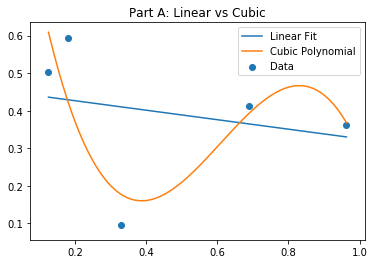


Part B

Degree: 1
MSE: 0.026737572016028444
R^2: 0.057749024069525756

Degree: 2
MSE: 0.020288694189455062
R^2: 0.28501204638518296

Degree: 3
MSE: 0.00943491987850541
R^2: 0.6675067407759311

Degree: 4
MSE: 2.9006390833073314e-27
R^2: 1.0

Degree: 5
MSE: 1.1371676467793766e-28
R^2: 1.0


/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


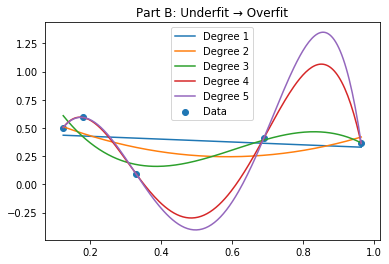


Part C (Vandermonde)
MSE: 0.00943491987850542
R^2: 0.6675067407759308


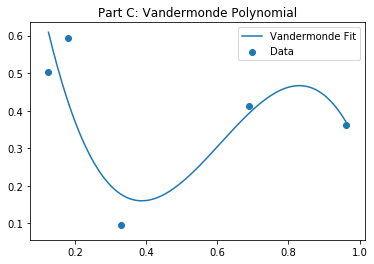

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# generate 5 random points
X = np.random.rand(5)
Y = np.random.rand(5)

idx = np.argsort(X)
X = X[idx]
Y = Y[idx]


def mse(y,yhat):
    return np.mean((y-yhat)**2)

def r2(y,yhat):
    ss_res = np.sum((y-yhat)**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    return 1 - ss_res/ss_tot

xline = np.linspace(min(X),max(X),200)


# Part A

A = np.vstack([X,np.ones(len(X))]).T
m,b = np.linalg.lstsq(A,Y,rcond=None)[0]

Y_ls = m*X + b

coeffs = np.polyfit(X,Y,3)
poly = np.poly1d(coeffs)
Y_poly = poly(X)

print("Part A")

print("Linear Fit")
print("MSE:",mse(Y,Y_ls))
print("R^2:",r2(Y,Y_ls))

print("\nCubic Polynomial")
print("MSE:",mse(Y,Y_poly))
print("R^2:",r2(Y,Y_poly))

plt.figure()

plt.scatter(X,Y,label="Data")

plt.plot(xline,m*xline+b,label="Linear Fit")
plt.plot(xline,poly(xline),label="Cubic Polynomial")

plt.legend()
plt.title("Part A: Linear vs Cubic")

plt.show()

# Part B


print("\nPart B")

plt.figure()
plt.scatter(X,Y,label="Data")

degrees = [1,2,3,4,5]

for d in degrees:

    coeffs = np.polyfit(X,Y,d)
    poly = np.poly1d(coeffs)

    Y_pred = poly(X)

    print("\nDegree:",d)
    print("MSE:",mse(Y,Y_pred))
    print("R^2:",r2(Y,Y_pred))

    plt.plot(xline,poly(xline),label="Degree "+str(d))

plt.legend()
plt.title("Part B: Underfit → Overfit")

plt.show()


# Part C


print("\nPart C (Vandermonde)")

degree = 3

V = np.vander(X,degree+1)

coeffs_v = np.linalg.lstsq(V,Y,rcond=None)[0]

poly_v = np.poly1d(coeffs_v)

Y_v = poly_v(X)

print("MSE:",mse(Y,Y_v))
print("R^2:",r2(Y,Y_v))

plt.figure()

plt.scatter(X,Y,label="Data")
plt.plot(xline,poly_v(xline),label="Vandermonde Fit")

plt.legend()
plt.title("Part C: Vandermonde Polynomial")

plt.show()

In [ ]:
##In Part A, the polynomial fit was better, with a smaller MSE and higher R^2